In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 609
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 609
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam0 : 639
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam1 : 640
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam0 : 714
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam1 : 708
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam0 : 741
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam1 : 733
INFO     | _get_names | Image Pair Counts : MGO13_sudden_movements cam0 : 746
INFO     | _get_na

In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

rotations = batch.rotations
print(rotations.shape)

torch.Size([92, 3, 32, 32]) torch.Size([92, 3, 32, 32])
torch.Size([92, 2]) torch.Size([92, 2])
torch.Size([92])


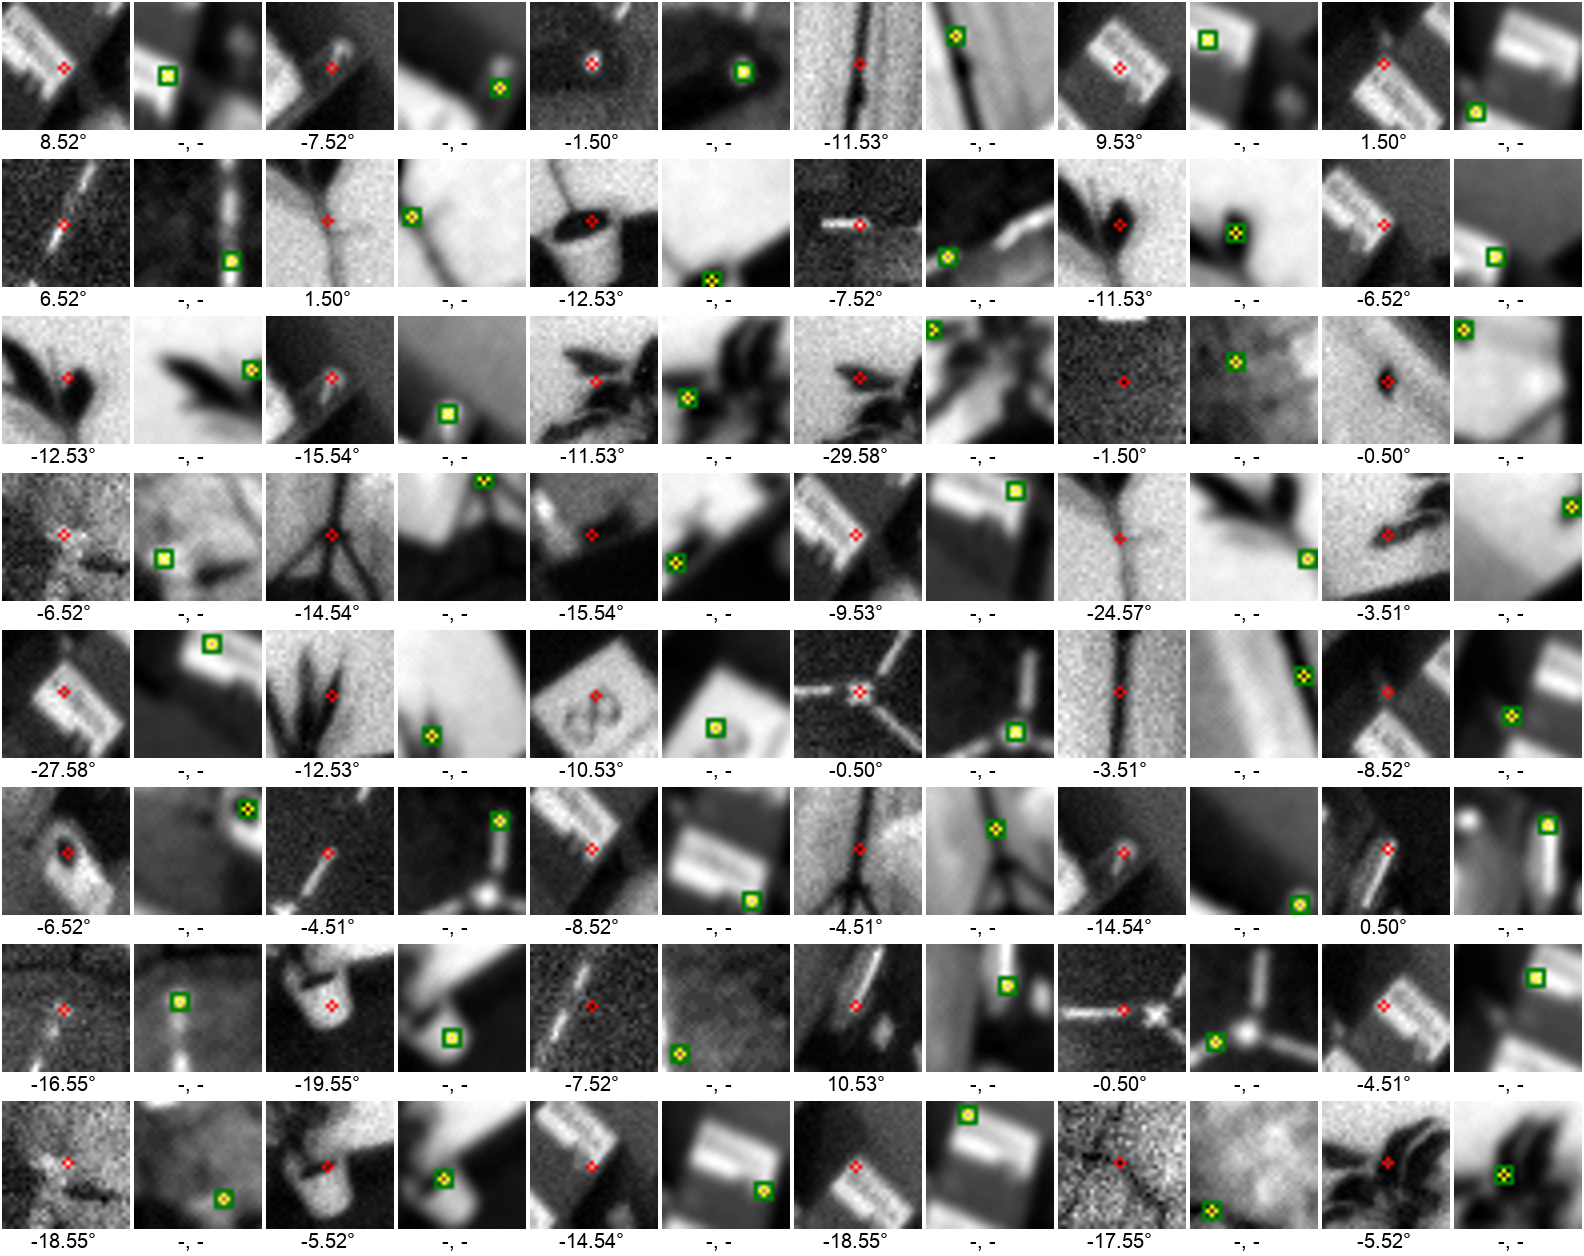

In [7]:
batch = next(iter(dl))

count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))
# print(batch.rotations[:count])

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    rotations_true=batch.rotations,
    rotations=None,
    limit_count=count, 
    n_columns=6,
)

In [8]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

In [9]:
dm.teardown()

# Check Model

In [10]:
from src import Light
light = Light()

In [11]:
from utils import count_params
count_params(light.model)

437348

In [12]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

target_coords, target_rotation, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

Model Inputs
reference_patches shape : torch.Size([92, 3, 32, 32])
target_patches shape : torch.Size([92, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([92, 2])
Model Outputs


OutOfMemoryError: CUDA out of memory. Tried to allocate 92.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 61.62 MiB is free. Process 733264 has 3.57 GiB memory in use. Process 1138814 has 44.00 MiB memory in use. Including non-PyTorch memory, this process has 262.00 MiB memory in use. Of the allocated memory 193.23 MiB is allocated by PyTorch, and 14.77 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Confidence

In [40]:
patch_level_reference_coords[:1], target_coords[:1]

(tensor([[15.5000, 16.5000]], device='cuda:0'),
 tensor([[-0.0401, -0.7722]], device='cuda:0', grad_fn=<SliceBackward0>))

In [41]:
std_dev = 6.0
covariance_matrix = torch.diag(torch.tensor([std_dev ** 2, std_dev ** 2], device=patch_level_reference_coords.device))

gaussian = torch.distributions.MultivariateNormal(
    loc=patch_level_reference_coords, 
    covariance_matrix=covariance_matrix
)

In [42]:
# X = (target_coords + 1) * 15.5

# X = patch_level_reference_coords + 10  # for testing std dev

d = torch.arange(patch_level_reference_coords.shape[0], device=patch_level_reference_coords.device).unsqueeze(1)
X = patch_level_reference_coords + d  # for testing std dev

raw_probabilities = torch.exp(gaussian.log_prob(X))

In [43]:
# Y = patch_level_reference_coords / 31.0
# max_probabilities = torch.exp(gaussian.log_prob(Y))
max_probabilities = torch.exp(gaussian.log_prob(patch_level_reference_coords))

# Normalize probabilities to make p = 1 when coords_pred = coords
normalized_probabilities = raw_probabilities / (max_probabilities + 0.000001)

In [44]:
normalized_probabilities[:15]

tensor([0.9998, 0.9724, 0.8946, 0.7786, 0.6410, 0.4992, 0.3678, 0.2563, 0.1690,
        0.1054, 0.0622, 0.0347, 0.0183, 0.0091, 0.0043], device='cuda:0')